## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [5]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

import models
import lossCalculator
import correlator
import tensorflow as tf

In [6]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [7]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)
spec2BWOmega = physicsHelper.BWfunOverOmega(A,Ga,M,omega)
# # plt.plot(omega,spec1BW,label=r'1 BW peak')
# plt.plot(omega,spec2BW, label=r'2 BW peaks')
# #plt.plot(omega,spec3BW, label=r'3 BW peaks')

# plt.legend()
# plt.xlim(0,10)


In [8]:
N_t=24
def get_bm_rho(w):
    beta_T = N_t
    omega_0 = 0.319
    eta = 2.30
    k_0 = 1.092 
    if N_t == 16:
        A_T = 0.00918
        gamma_T = 0.259
        k_1 = -0.094
        rho = 3*(k_0+k_1*(1-np.tanh(w/(omega_0*eta))**2))/(4*np.pi**2)*w**2 *np.tanh(w*beta_T/4)+w*A_T*gamma_T/(np.pi*(gamma_T**2 + w**2))
    if N_t == 24:
        rho = np.zeros(len(w))
        m_v = 0.206
        a_T = 0.00086
        gamma_T = 0.03
        k_o = -0.00014
        A_T = 0.00032
        for i in range(len(w)):
            rho[i] += w[i]*A_T*gamma_T/(np.pi*(gamma_T**2 + w[i]**2))
            if w[i] <= m_v + 0.001 and w[i] >= m_v - 0.001:
                rho[i] += a_T
            if w[i] >= omega_0:
                rho[i] += 3*k_0/(4*np.pi**2) * w[i]**2 * np.tanh(w[i]*N_t/4) + 3*k_o/(4*np.pi**2) *1/(w[i]**2)
    return 2*np.pi*rho


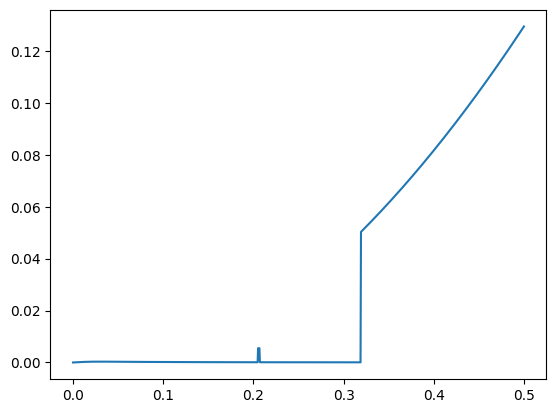

In [10]:
wr=np.linspace(0,0.5,1000)

plt.plot(wr,get_bm_rho(wr))

In [4]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

2024-12-06 14:29:42.876679: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

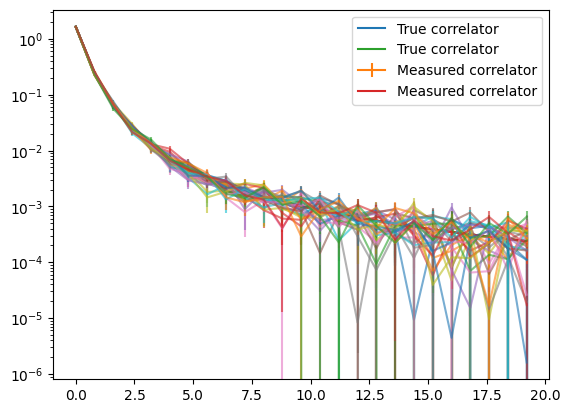

In [5]:
# Preparing the tensor of noise vectors
ep_noise=0#3e-2
noisy_dxi_tensor = []
num_samples = 30
noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi,custom_std, label=r'Measured correlator')
ep_noise=3e-2
if num_samples == 1:
    noisy_dxi_tensor.append(noisy_Dxi)
else:
    for ii in range(num_samples):
        noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
        noisy_dxi_tensor.append(noisy_Dxi_sample)


plt.plot(x,Dxi, label=r'True correlator')
plt.errorbar(x,noisy_Dxi, label=r'Measured correlator')
# plt.plot(x,noisy_Dxi, label=r'Noisy correlator')
for i in range(len(noisy_dxi_tensor)):
    plt.errorbar(x, noisy_dxi_tensor[i],custom_std,  alpha=0.6)

plt.yscale('log')

plt.legend()

In [6]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop
from multiprocessing import Pool


# Create input data and target
 # Constant input node which goes to 500 omegas as the NN structure in paper
# target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 1.0e-2
lambda_l2_warmup = 1.0e-4
lambda_s = 6.9877915950256485e-06#3.55323189e-05#1.0e-5#1.0e-4
lambda_l2 = 2.3667835227018086e-07#6.66754659e-08#1.0e-8
epochs=1000
new_epochs = 30000

# num_samples = 30
gauss_width = np.ones(len(x)) #for mean square error
# gauss_width=custom_std


constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
# constant_input = tf.constant(omega, dtype=tf.float32)  #NNP2p
# constant_input = tf.reshape(constant_input, (-1, 1)) #NNP2p
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
kern=klW_ker_Pos
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)


model = models.SpectralNN(num_output_nodes=500, width=64, depth=3)
target_output = tf.constant(noisy_Dxi, dtype=tf.float32)
target_output=noisy_dxi_tensor
lossCalc=lossCalculator.LossCalculator(model=model,
                                    y_true=target_output,
                                    kernel=kern,
                                    delomega=del_omega,
                                    x=constant_input,
                                    std=gauss_width,
                                    lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                    lambda_s_func=lambda x:lambda_s,
                                    lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                    lambda_l2_func=lambda x:lambda_l2
                                        )
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
trainer=models.networkTrainer(model,optimizer,lossCalc)
total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
trainer.optimizer=optimizer
total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)
rho=model(constant_input)








Training for 1000 epochs
Epoch 0, Loss: 748.6056518554688
Epoch 100, Loss: 0.34372013807296753
Epoch 200, Loss: 0.10291339457035065
Epoch 300, Loss: 0.03783879801630974
Epoch 400, Loss: 0.015987534075975418
Epoch 500, Loss: 0.00774513091892004
Epoch 600, Loss: 0.004450264386832714
Epoch 700, Loss: 0.0031084930524230003
Epoch 800, Loss: 0.002566966461017728
Epoch 900, Loss: 0.0023544090799987316
Training took 7.299084663391113 seconds
Training for 30000 epochs
Epoch 0, Loss: 0.0022739460691809654
Epoch 3000, Loss: 7.246779568959028e-05
Epoch 6000, Loss: 5.1017523219343275e-05
Epoch 9000, Loss: 4.719010757980868e-05
Epoch 12000, Loss: 4.364235428511165e-05
Epoch 15000, Loss: 4.02449986722786e-05
Epoch 18000, Loss: 3.7210204027360305e-05
Epoch 21000, Loss: 3.449587165960111e-05
Epoch 24000, Loss: 3.206948531442322e-05
Epoch 27000, Loss: 2.990144093928393e-05
Training took 213.03807497024536 seconds


In [7]:
# np.save('data/rho_Multifit_30_corrs_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_NN',loss_history)

np.save('data/rho_Multifit_30_corrs_rhoFit_NN',rho)
np.save('data/total_loss_history_Multifit_30_corrs_rhoFit_NN',total_loss_history)
np.save('data/loss_history_Multifit_30_corrs_rhoFit_NN',loss_history)

In [23]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

Text(0, 0.5, '$\\rho/\\omega$')

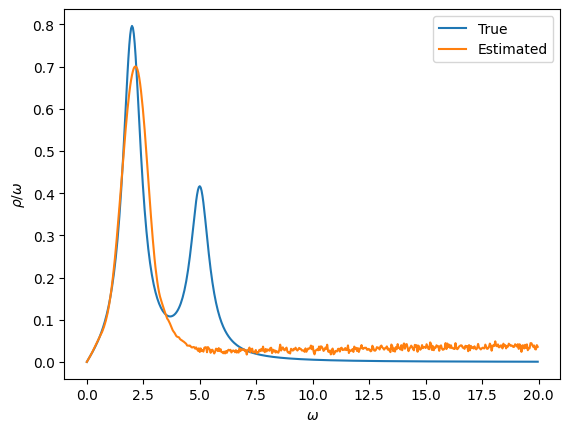

In [17]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,np.squeeze(rho)*omega, label=r'Estimated',color='C1',marker='')
plt.legend()
# plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


Text(0, 0.5, '$\\rho/\\omega$')

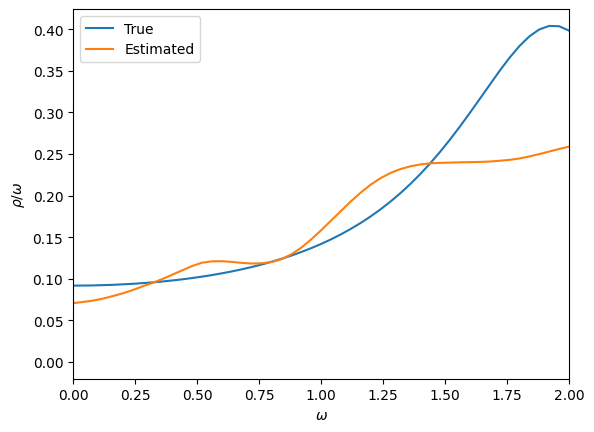

In [11]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BWOmega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_14375/2786768227.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

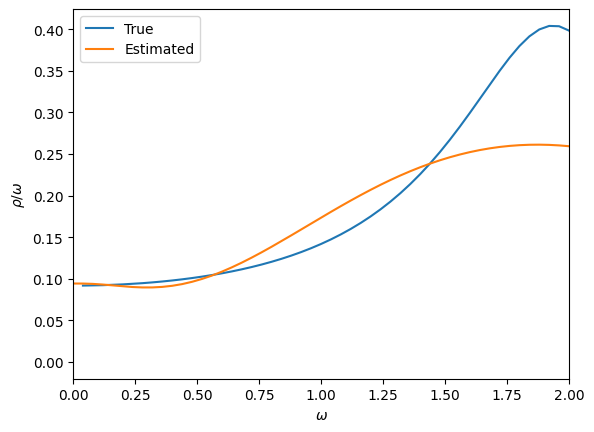

In [ ]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BWOmega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_14375/1572968319.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

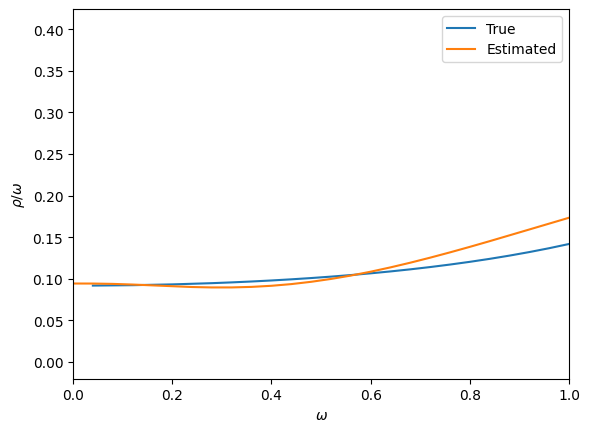

In [37]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,1)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_14375/3309905304.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

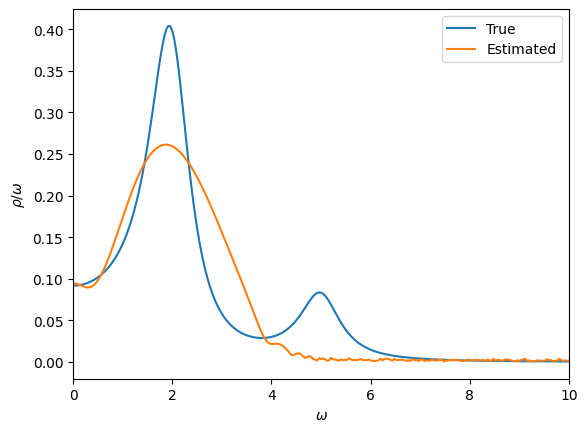

In [40]:
# singlefit result with 1 correlators
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,np.squeeze(rho), label=r'Estimated',color='C1')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


Text(0.5, 0, 'Epochs')

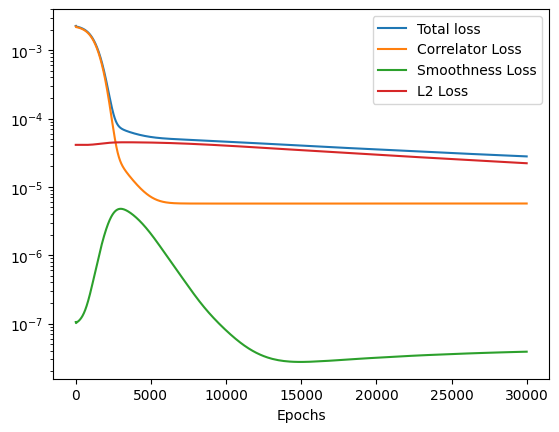

In [10]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,total_loss_history,label=r'Total loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[0],label=r'Correlator Loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[1]*lambda_s,label=r'Smoothness Loss')
plt.plot(trainingepochs,np.squeeze(loss_history).T[2]*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

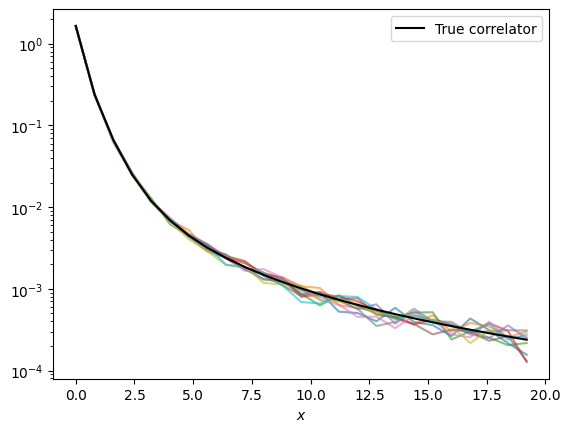

In [13]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.6)
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

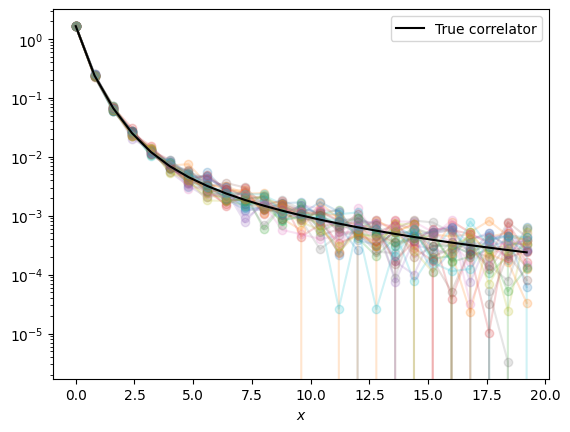

In [9]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.2,ls='-',marker='o')
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

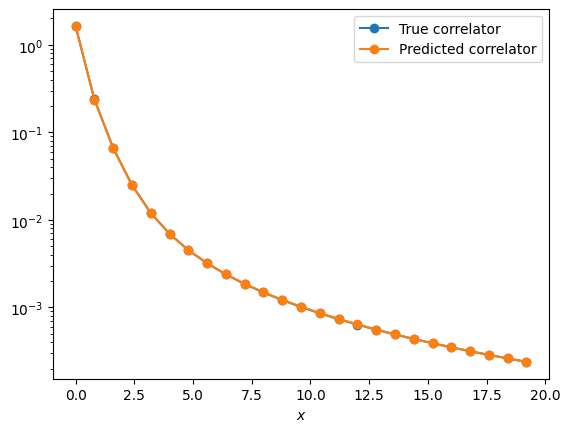

In [12]:
plt.plot(x,Dxi, label=r'True correlator',marker='o')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator

klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)

plt.plot(x,Dxi_prediction, label=r'Predicted correlator',marker='o')
plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.show()

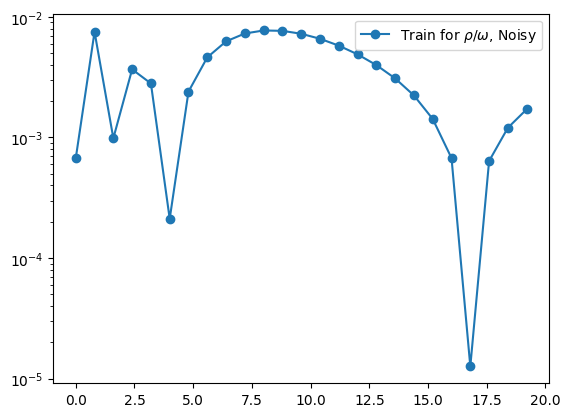

In [13]:
compareCorrelator=noisy_Dxi
plt.plot(x,np.abs(Dxi_prediction-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
# plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

In [19]:
compareCorrelator=Dxi
plt.plot(x,np.abs(Final_DxiWNoisy-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy',marker='o')
plt.plot(x,np.abs(Final_DxiWNoisy_stderror-compareCorrelator)/compareCorrelator, label=r'Train for $\rho/\omega$, Noisy with std error',marker='o')
plt.yscale('log')
plt.legend()
plt.show()

NameError: name 'Dxi' is not defined

# Behaviour of the kernal with $\omega$ and $p$.  

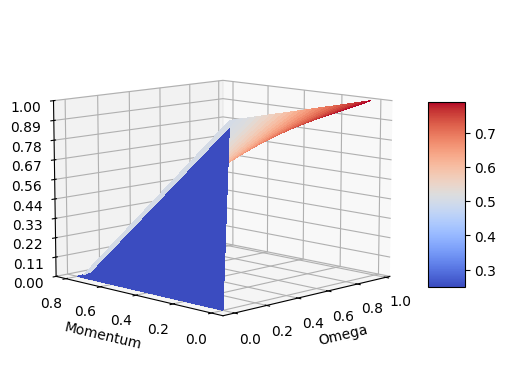

In [ ]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [ ]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [ ]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [ ]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

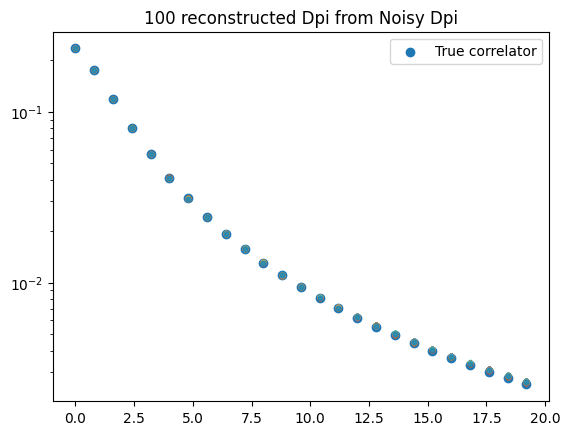

In [ ]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

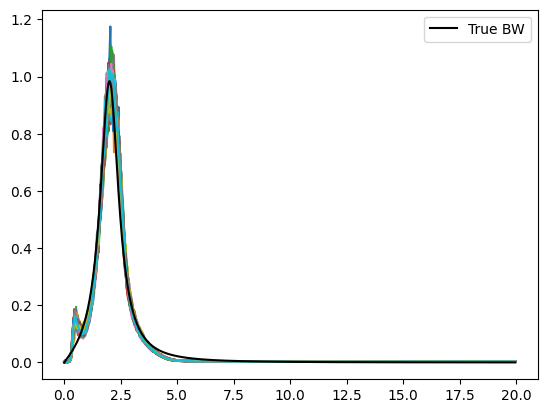

In [ ]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [ ]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [ ]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

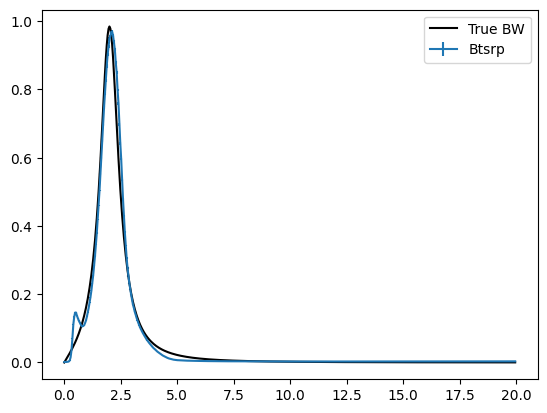

In [ ]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()